In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        (os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import DenseNet121

2026-04-07 12:24:14.156116: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775564654.341001    1983 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775564654.393879    1983 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775564654.811624    1983 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775564654.811659    1983 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775564654.811661    1983 computation_placer.cc:177] computation placer alr

In [3]:
csv_path = "/kaggle/input/datasets/amimulahasanrofik/abu-csv/data_info.csv"
img_dir = "/kaggle/input/datasets/amimulahasanrofik/abu-sayed/Fundus_CIMT_2903 Dataset"

df = pd.read_csv(csv_path)

df['path'] = df['image_name'].apply(lambda x: os.path.join(img_dir, x))
df.head()

,image_name,thickness,label,True_age,age,gender,group,path
0,2491006_R.png,0.8,0,63,0.684932,0,1,/kaggle/input/datasets/amimulahasanrofik/abu-s...
1,2491006_L.png,0.8,0,63,0.684932,0,1,/kaggle/input/datasets/amimulahasanrofik/abu-s...
2,3730004_R.png,1.2,1,61,0.657534,1,1,/kaggle/input/datasets/amimulahasanrofik/abu-s...
3,3730004_L.png,1.2,1,61,0.657534,1,1,/kaggle/input/datasets/amimulahasanrofik/abu-s...
4,3730006_R.png,1.2,1,64,0.698630,1,1,/kaggle/input/datasets/amimulahasanrofik/abu-s...


In [4]:
IMG_SIZE = 224

images = []

for i in tqdm(range(len(df))):
    img = cv2.imread(df['path'][i])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    images.append(img)

X_img = np.array(images)

100%|██████████| 5806/5806 [01:51<00:00, 52.01it/s]


In [5]:
tabular_cols = ['thickness', 'True_age', 'age', 'gender', 'group']

X_tab = df[tabular_cols].values

In [6]:
scaler = StandardScaler()
X_tab = scaler.fit_transform(X_tab)

In [7]:
le = LabelEncoder()
y = le.fit_transform(df['label'])

num_classes = len(np.unique(y))

In [8]:
X_img_train, X_img_test, X_tab_train, X_tab_test, y_train, y_test = train_test_split(
    X_img, X_tab, y, test_size=0.2, stratify=y, random_state=42
)

In [9]:
image_input = layers.Input(shape=(224,224,3))

base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_tensor=image_input
)

for layer in base_model.layers:
    layer.trainable = False

x1 = base_model.output
x1 = layers.GlobalAveragePooling2D()(x1)
x1 = layers.BatchNormalization()(x1)

I0000 00:00:1775564787.134734    1983 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [10]:
tabular_input = layers.Input(shape=(X_tab.shape[1],))

x2 = layers.Dense(64, activation='relu')(tabular_input)
x2 = layers.BatchNormalization()(x2)
x2 = layers.Dropout(0.3)(x2)

x2 = layers.Dense(32, activation='relu')(x2)

In [11]:
combined = layers.Concatenate()([x1, x2])

In [12]:
x = layers.Dense(256, activation='relu')(combined)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.4)(x)

output = layers.Dense(num_classes, activation='softmax')(x)

In [13]:
model = models.Model(
    inputs=[image_input, tabular_input],
    outputs=output
)

In [14]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
history = model.fit(
    [X_img_train, X_tab_train],
    y_train,
    validation_data=([X_img_test, X_tab_test], y_test),
    epochs=10,
    batch_size=16
)

Epoch 1/10


I0000 00:00:1775564812.648752    2027 service.cc:152] XLA service 0x7db360004210 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775564812.649961    2027 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775564816.293878    2027 cuda_dnn.cc:529] Loaded cuDNN version 91002


  3/291 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.3264 - loss: 2.0074   

I0000 00:00:1775564829.150499    2027 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


291/291 ━━━━━━━━━━━━━━━━━━━━ 79s 170ms/step - accuracy: 0.5735 - loss: 1.0818 - val_accuracy: 0.8434 - val_loss: 0.3506
Epoch 2/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - accuracy: 0.8086 - loss: 0.4898 - val_accuracy: 0.9346 - val_loss: 0.1471
Epoch 3/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - accuracy: 0.8759 - loss: 0.3344 - val_accuracy: 0.9836 - val_loss: 0.0673
Epoch 4/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - accuracy: 0.9155 - loss: 0.2212 - val_accuracy: 0.9948 - val_loss: 0.0386
Epoch 5/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - accuracy: 0.9276 - loss: 0.1910 - val_accuracy: 0.9974 - val_loss: 0.0276
Epoch 6/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - accuracy: 0.9395 - loss: 0.1634 - val_accuracy: 0.9983 - val_loss: 0.0200
Epoch 7/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - accuracy: 0.9522 - loss: 0.1399 - val_accuracy: 1.0000 - val_loss: 0.0130
Epoch 8/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - accuracy: 0.9516 - loss: 0.1472 - val_accura

In [16]:
# for layer in base_model.layers[-10:]:
#     layer.trainable = True

# model.compile(
#     optimizer=tf.keras.optimizers.Adam(1e-5),
#     loss='sparse_categorical_crossentropy',
#     metrics=['accuracy']
# )

# history_fine = model.fit(
#     [X_img_train, X_tab_train],
#     y_train,
#     validation_data=([X_img_test, X_tab_test], y_test),
#     epochs=15,
#     batch_size=16
# )

In [17]:
# # 1. Freeze most layers
# for layer in base_model.layers[:-20]:
#     layer.trainable = False
# for layer in base_model.layers[-20:]:
#     layer.trainable = True

# # 2. Reduce batch size
# batch_size = 8

# # 3. Compile and train
# model.compile(
#     optimizer=tf.keras.optimizers.Adam(1e-5),
#     loss='sparse_categorical_crossentropy',
#     metrics=['accuracy']
# )

# history_fine = model.fit(
#     [X_img_train, X_tab_train],
#     y_train,
#     validation_data=([X_img_test, X_tab_test], y_test),
#     epochs=15,
#     batch_size=batch_size
# )

In [18]:
loss, acc = model.evaluate([X_img_test, X_tab_test], y_test)
print("Accuracy:", acc)

37/37 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 1.0000 - loss: 0.0085
Accuracy: 1.0


37/37 ━━━━━━━━━━━━━━━━━━━━ 24s 365ms/step
Confusion Matrix:
 [[340   0]
 [  0 822]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       340
           1       1.00      1.00      1.00       822

    accuracy                           1.00      1162
   macro avg       1.00      1.00      1.00      1162
weighted avg       1.00      1.00      1.00      1162



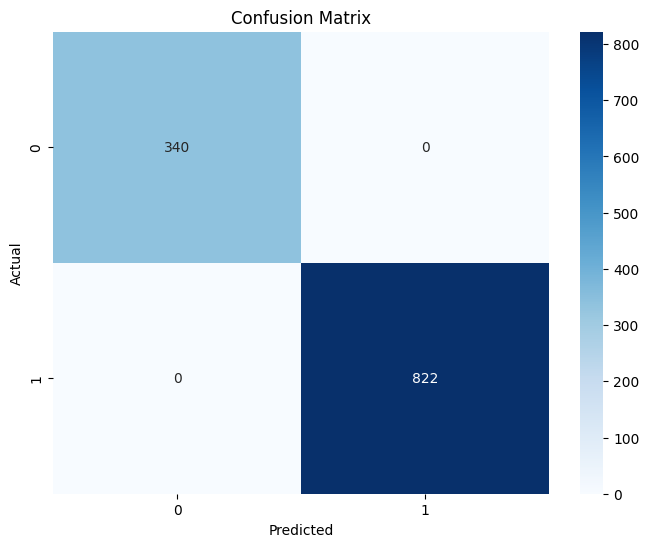

In [19]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Predict on the test set
y_pred_probs = model.predict([X_img_test, X_tab_test])
# If it's a classification problem with one-hot or softmax output, get class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# 3. Optional: classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 4. Visualize confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()